# 01 - Exploratory Data Analysis

Exploration of `ml/data/creditcard.csv`. This notebook is for looking at the data only; reusable code lives in `ml/src/`.

In [1]:
import os, sys

# Make the repo root importable so `ml.src` works from inside ml/notebooks/
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.src.data import load_raw, drop_duplicates, split, summarize

## Shape, types, missing values

In [2]:
df = load_raw()
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df.isna().sum().sum()

np.int64(0)

## Class balance

In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [6]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

## Duplicates

In [7]:
print('exact duplicate rows:', df.duplicated().sum())
print('fraud among duplicates:', df[df.duplicated()]['Class'].sum())
df = drop_duplicates(df)

exact duplicate rows: 1081
fraud among duplicates: 19
Dropped 1081 duplicate rows (284807 -> 283726)


## Amount

In [8]:
df.groupby('Class')['Amount'].describe(percentiles=[.25, .5, .75, .95, .99])

,count,mean,std,min,25%,50%,75%,95%,99%,max
Class,,,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,365.00,1018.0576,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,655.82,1364.1368,2125.87


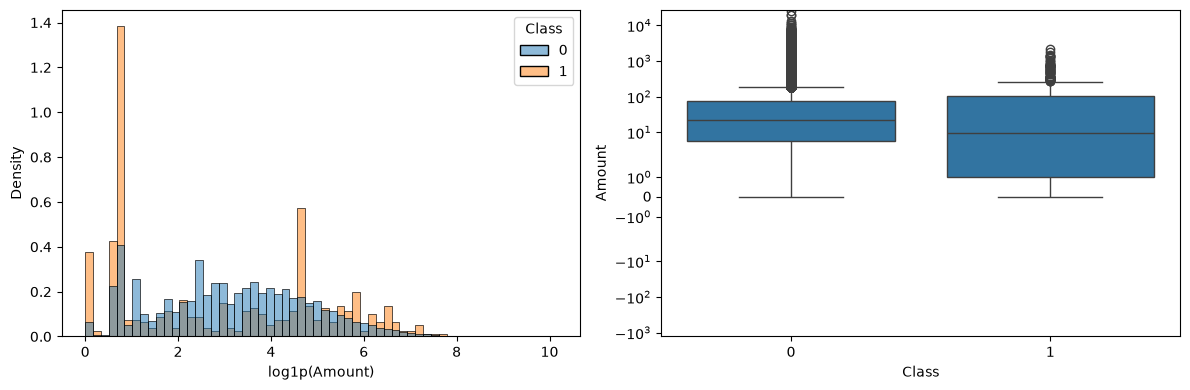

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x=np.log1p(df['Amount']), hue='Class', stat='density', common_norm=False, bins=60, ax=axes[0])
axes[0].set_xlabel('log1p(Amount)')
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[1])
axes[1].set_yscale('symlog')
plt.tight_layout()

## Time

`Time` is seconds since the first transaction (48 hours total), not a wall-clock time.

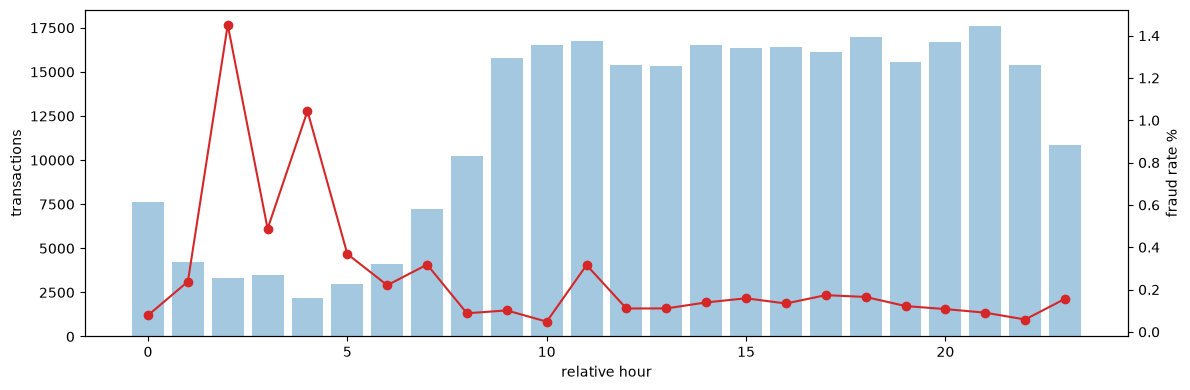

In [10]:
hour = (df['Time'] // 3600 % 24).astype(int)
by_hour = df.groupby(hour)['Class'].agg(['count', 'sum', 'mean'])
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.bar(by_hour.index, by_hour['count'], alpha=0.4, label='transactions')
ax1.set_xlabel('relative hour')
ax1.set_ylabel('transactions')
ax2 = ax1.twinx()
ax2.plot(by_hour.index, by_hour['mean'] * 100, color='C3', marker='o', label='fraud rate %')
ax2.set_ylabel('fraud rate %')
plt.tight_layout()

## Extreme values in V1-V28

In [11]:
V = [f'V{i}' for i in range(1, 29)]
z = (df[V] - df[V].mean()) / df[V].std()
extreme = (z.abs() > 10).any(axis=1)
print('rows with any |z| > 10:', extreme.sum(), '| fraud among them:', df.loc[extreme, 'Class'].sum())
(z.abs() > 10).sum().sort_values(ascending=False).head(10)

rows with any |z| > 10: 1901 | fraud among them: 214


V21    475
V8     408
V23    381
V20    324
V28    316
V27    312
V7     259
V2     241
V17    207
V10    204
dtype: int64

In [12]:
df[V + ['Amount', 'Time', 'Class']].corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)

V17    0.313498
V14    0.293375
V12    0.250711
V10    0.206971
V16    0.187186
V3     0.182322
V7     0.172347
V11    0.149067
V4     0.129326
V18    0.105340
Name: Class, dtype: float64

## Train / val / test split comparison

In [13]:
for strategy in ('stratified', 'time'):
    print(f'--- {strategy} ---')
    for name, part in zip(('train', 'val', 'test'), split(df, strategy=strategy)):
        summarize(name, part)

--- stratified ---
train  rows= 198608  fraud= 331  rate=0.1667%  time=[0, 172792]
val    rows=  42559  fraud=  71  rate=0.1668%  time=[10, 172782]
test   rows=  42559  fraud=  71  rate=0.1668%  time=[2, 172786]
--- time ---
train  rows= 198608  fraud= 366  rate=0.1843%  time=[0, 132906]
val    rows=  42559  fraud=  55  rate=0.1292%  time=[132906, 151320]
test   rows=  42559  fraud=  52  rate=0.1222%  time=[151320, 172792]
